# Gráficos de caja (*boxplots*)

## 1. ¿Qué son?

Son una manera de visualizar la distribución de los datos. Es decir no sólo una medida global (como las de tendencia central o de variabilidad) sino una "foto panorámica" de TODOS los datos.


## 2. Elementos de un *boxplot*

Un *boxplot* se obtiene:

1. Calculando los cuartiles 1, 2 y 3
2. Dibujando en una gráfica estos cuartiles dentro de una caja (de allí el nombre: *boxplot*) y agregando además lo que se conocen como los "bigotes" (*whiskers*) calculados también a partir de los cuartiles
3. Superponiendo cada uno de los datos de nuestra variable

![](elementos-boxplot.png)


    


Así, los elementos de un *boxplot* son:

- Los cuartiles 1 y 3 (límites inferior y superior de la caja)
- La mediana (línea central de la caja)
- Los *whiskers*:
    - El inferior es simplemente Q1 - 1.5*IQR (siendo IQR el rango intercuartiles)
    - El superior es simplemente Q3 + 1.5*IQR

## 3. ¿Cuándo usar un *boxplot*?

Cuando queremos ver la distribución detallada de los datos. Específicamente:

- Podemos ver la tendencia central (mediana) y la dispersión (IQR)
- Si hay simetría o asimetría (*skewness*) en la distribución
- Dentro de qué rango de valores se encuentra la mayor parte de los datos
- Si hay valores extremos

Además nos permite comparar distribuciones de variables (esto lo veremos más adelante en el análisis bivariado).

## 4. ¿Cómo generar gráficos tipo *boxplot*?

Para entender todo lo anterior podemos hacer un ejemplo práctico que nos permitirá ver cómo generar e interpretar este tipo de gráficas.

Comencemos cargando el set de datos *data-boxplots.csv*:

In [1]:
import pandas as pd

ruta = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/21-2024-03-Estadística-Descriptiva/datos/'
df = pd.read_csv(ruta + 'data-boxplots.csv')
df

,var1,var2
0,3.764052,3.620681
1,2.400157,3.187206
2,2.978738,3.368244
3,4.240893,3.999474
4,3.867558,2.694081
...,...,...
95,2.706573,4.019651
96,2.010500,3.164160
97,3.785870,2.848879
98,2.126912,3.398333


Tenemos dos variables (columnas *var1* y *var2*) y un total de 100 datos (filas).

Comencemos viendo la distribución de cada variable de manera individual. Podemos usar la librería *Seaborn* (lección 12 del curso "Pandas Nivel Intermedio") para generar gráficos de cajas de manera sencilla:

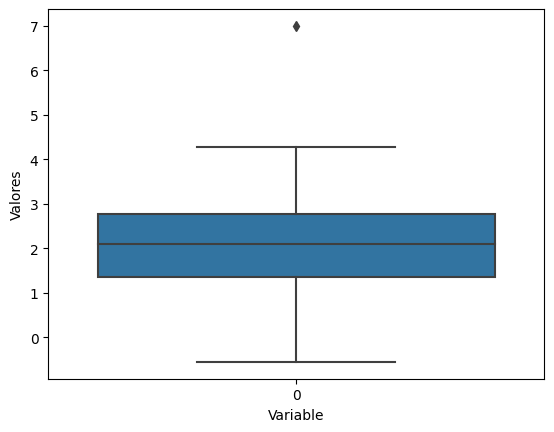

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot "var1"
ax = sns.boxplot(data=df['var1'])
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

Y con esta simple gráfica podemos concluir varias cosas acerca de la distribución de esta variable:

1. Tiene una mediana cercana a 2
2. Tiene un IQR de casi 1.5 (Q1 ~ 1.3, Q3 ~ 2.8)
3. La mayor parte de los datos se encuentra entre -0.5 y 4.3 aproximadamente
4. La distribución es ligeramente asimétrica: la mediana no está exactamente en la mitad de la caja. Los bigotes no están exactamente a la misma distancia de la caja.
5. Hay un valor extremo con un valor de 7 unidades


Veamos qué ocurre con la segunda variable:

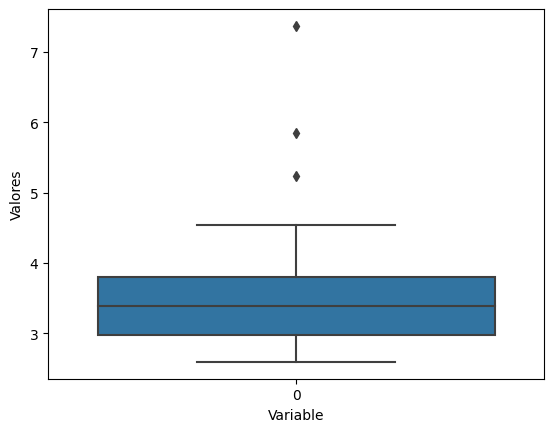

In [3]:
# Boxplot "var2"
ax = sns.boxplot(data=df['var2'])
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

Esta segunda variable se caracteriza por:

- Tener una media de aproximadamente 3.4 y un rango intercuartiles de aproximadamente 1
- El rango de valores está entre 2.5 y 4.7 aproximadamente
- La distribución es asimétrica
- Tiene 3 valores extremos

## 5. Opciones adicionales de visualización

Podemos por ejemplo superponer todos los datos originales al gráfico *boxplot*. Para ello usamos la gráfica `stripplot` de Seaborn:

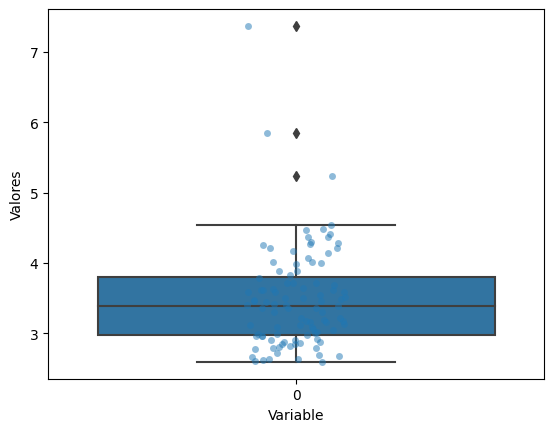

In [6]:
# Boxplot "var2" + datos completos
ax = sns.boxplot(data=df['var2'])
ax = sns.stripplot(data=df['var2'], jitter=True, alpha=0.5)
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

Y al llamar "boxplot" debemos desactivar la opción de mostrar los *outliers* (para que no se dibujen 2 veces):

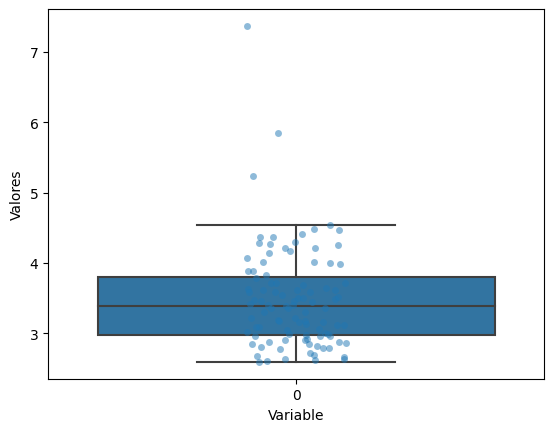

In [7]:
# Boxplot "var2" + datos completos - outliers repetidos
ax = sns.boxplot(data=df['var2'], showfliers=False)
ax = sns.stripplot(data=df['var2'], jitter=True, alpha=0.5)
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

Y podemos cambiar el color de los puntos de datos para verlos claramente:

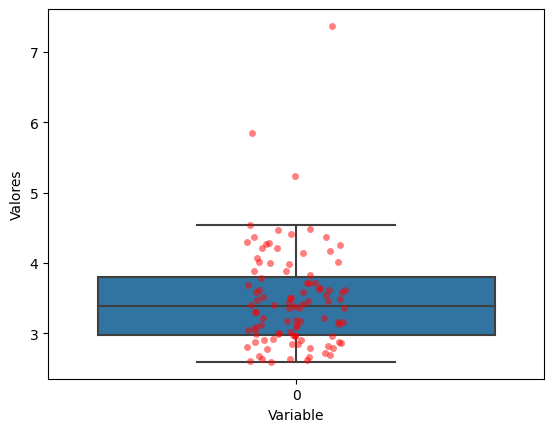

In [8]:
# Boxplot "var2" + datos completos - outliers repetidos
ax = sns.boxplot(data=df['var2'], showfliers=False)
ax = sns.stripplot(data=df['var2'], color='red', jitter=True, alpha=0.5)
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

## 6. Ejemplo práctico

Volvamos al set de datos *tasas-crimenes.csv* y analicemos la distribución de las variables población y tasa de asesinatos con ayuda de los gráficos de caja.

Comencemos leyendo el set de datos:

In [9]:
df = pd.read_csv(ruta + 'tasas-crimenes.csv')
df

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


Y ahora analicemos la población. Durante el Análisis Exploratorio de Datos se sugiere siempre escribir una breve observación después de usar cada herramienta de análisis:

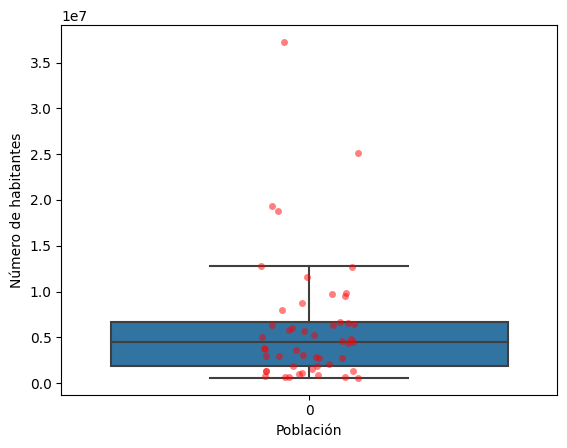

In [10]:
# Boxplot "población"
ax = sns.boxplot(data=df['Population'], showfliers=False)
ax = sns.stripplot(data=df['Population'], color='red', jitter=True, alpha=0.5)
ax.set_xlabel('Población')
ax.set_ylabel('Número de habitantes');

Observaciones:

- La mayor parte de los estados tienen entre 0.1 y 1.3 x 10^7 habitantes (es decir entre 1 y 13 millones de habitantes)
- 4 estados están por fuera del rango anterior, con poblaciones entre casi 20, 25 e incluso 37 millones de habitantes
- La mediana de población en los estados es de aproximadamente 5'000.000 habitantes.
- Dispersión (IQR) aprox. 0.7-0.25 x 10^7 = 0.45 x 10^7 = 4.5 millones

Veamos lo que ocurre ahora con la tasa de asesinatos:

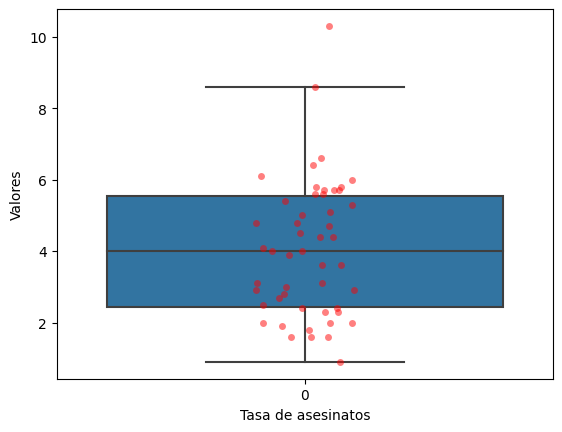

In [11]:
# Boxplot "tasa de asesinatos"
ax = sns.boxplot(data=df['Murder.Rate'], showfliers=False)
ax = sns.stripplot(data=df['Murder.Rate'], color='red', jitter=True, alpha=0.5)
ax.set_xlabel('Tasa de asesinatos')
ax.set_ylabel('Valores');

Observaciones:

- La mediana de asesinatos es de 4 por cada 100.000 habitantes
- La tasa de asesinatos está entre 1 y 5.7 asesinatos por cada 100.000 habitantes
- Hay un estado con una tasa extremadamente alta y muy superior a la de los demás estados. Este estado tiene una tasa de más de 10 asesinatos por cada 100.000 habitantes

## 4. Aspectos a tener en cuenta

- Podemos usar *boxplots* para ver en una sola gráfica tendencia central, dispersión, simetría, distribución de los datos y valores extremos
- Siempre se sugiere escribir unas breves observaciones tras realizar el análisis de la gráfica